In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import chisquare
import dataquality as dq
from scipy.stats import shapiro
from scipy.stats import pearsonr
from scipy.stats import spearmanr

In [2]:
sf_parks = pd.read_csv('sf_parks.csv')
sf_parks

,neighborhood,num_parks,pop_density,avg_income
0,Neighborhood 1,9,3945,82458
1,Neighborhood 2,5,5820,81444
2,Neighborhood 3,6,5463,94137
3,Neighborhood 4,5,5279,75986
4,Neighborhood 5,5,5338,69829
...,...,...,...,...
95,Neighborhood 96,4,4556,75425
96,Neighborhood 97,12,6078,95434
97,Neighborhood 98,1,2440,78915
98,Neighborhood 99,6,6181,70990


### Top 5 Rows



,neighborhood,num_parks,pop_density,avg_income
0,Neighborhood 1,9,3945,82458
1,Neighborhood 2,5,5820,81444
2,Neighborhood 3,6,5463,94137
3,Neighborhood 4,5,5279,75986
4,Neighborhood 5,5,5338,69829


### Bottom 5 Rows



,neighborhood,num_parks,pop_density,avg_income
95,Neighborhood 96,4,4556,75425
96,Neighborhood 97,12,6078,95434
97,Neighborhood 98,1,2440,78915
98,Neighborhood 99,6,6181,70990
99,Neighborhood 100,3,4368,103283


### Random Sample



...

np.int64(0)

### Statistics Summary



,num_parks,pop_density,avg_income
count,100.000000,100.000000,100.000000
mean,4.840000,4913.120000,77631.260000
std,2.364382,1122.192805,13712.855511
min,1.000000,2344.000000,34307.000000
25%,3.000000,4183.750000,69794.250000
50%,5.000000,4853.500000,78289.500000
75%,6.000000,5830.500000,86340.500000
max,12.000000,7696.000000,110168.000000


### First 10 Values Chart



,index,0
0,neighborhood,100
1,num_parks,12
2,pop_density,99
3,avg_income,100


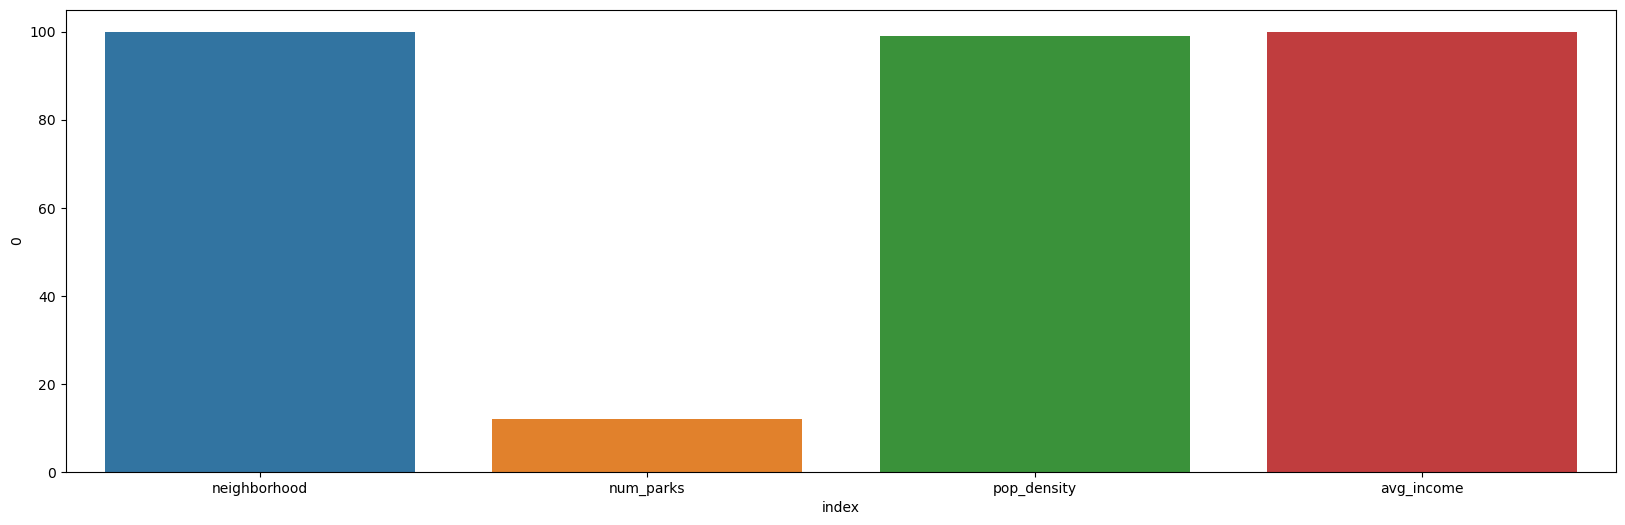

In [4]:
dq.data_check(sf_parks)

In [13]:
#Prepare data for Chi-Square test
sf_parks['pop_density_cat'] = pd.cut(sf_parks['pop_density'],
                                     bins=3,
                                     labels=['Low','Medium','High'])

contingency_table = pd.crosstab(sf_parks['pop_density_cat'],sf_parks['num_parks'])



statistic, pvalue, dof, expected = chi2_contingency(contingency_table)

results = {'chi2 statistic': statistic,
           'p-value': pvalue}


           
print(f'Chi Statistic: {statistic: .4f}')
print(f'P-value: {pvalue: .4f}')
print(f'Degrees of Freedom: {dof}')
print(f'Results Stored: {results}')

Chi Statistic:  14.9784
P-value:  0.8632
Degrees of Freedom: 22
Results Stored: {'chi2 statistic': np.float64(14.978419331764101), 'p-value': np.float64(0.8631624550518825)}


In [14]:
#Perform Chi-Square test for average income
sf_parks['avg_income_cat'] = pd.cut(sf_parks['avg_income'],
                                     bins=3,
                                     labels=['Low','Medium','High'])

contingency_table2 = pd.crosstab(sf_parks['avg_income_cat'],sf_parks['num_parks'])

chi2, p_income, dof_income, expected_income = chi2_contingency(contingency_table2)

results_income = {'chi2 statistic': chi2,
           'p-value': p_income}

print(f'Chi Statistic: {chi2: .4f}')
print(f'P-value: {p_income: .4f}')
print(f'Degrees of Freedom: {dof_income}')
print(f'Results Stored: {results_income}')

Chi Statistic:  15.3466
P-value:  0.8469
Degrees of Freedom: 22
Results Stored: {'chi2 statistic': np.float64(15.346552035129621), 'p-value': np.float64(0.8469413938097651)}


### Based on the pvalue on both population density and average income both do not have any statistical significance when it comes to the num of parks

In [16]:
#Calculate the correlation coefficients between the number of parks and population density

stat_parks, p_parks = shapiro(sf_parks['num_parks'])
stat_density, p_density = shapiro(sf_parks['pop_density'])

print(f'num_parks p-value: {p_parks}')
print(f'pop_density p-value: {p_density}')

num_parks p-value: 0.0029943533404083633
pop_density p-value: 0.6433037561926196


In [20]:
corr, p = spearmanr(sf_parks['num_parks'], sf_parks['pop_density'])

print(f'Spearman Correlation: {corr: .4f}')
print(f'P-value: {p: .4f}')

Spearman Correlation: -0.0285
P-value:  0.7784


In [21]:
#Calculate the correlation coefficients between the number of parks and average income
stat_income, p_income = shapiro(sf_parks['avg_income'])

print(f'num_parks p-value: {p_parks}')
print(f'pop_density p-value: {p_income}')

num_parks p-value: 0.0029943533404083633
pop_density p-value: 0.6980968665843511


In [22]:
corr_income, p_income = spearmanr(sf_parks['num_parks'], sf_parks['avg_income'])

print(f'Spearman Correlation: {corr_income: .4f}')
print(f'P-value: {p_income: .4f}')

Spearman Correlation:  0.1230
P-value:  0.2229


## Check if there is a significant correlation between the number of parks and average income
### With a correlation of 0.1230 and a P-value of 0.2229 it shows that there is little to is a very light positive correlation between the number of parks and average income but it is not statistically significant suggesting no meaningful correlation